In [4]:
!pip install -q torchmetrics
!pip install grad-cam
!pip install -q albumentations
!pip install -q timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 51.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=2949f5bcdcff60570d337b9b512207af090f257e1c453672c9bb81da3311e07f
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [14]:
!pip install -q monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 45.7 MB/s eta 0:00:00a 0:00:01


In [5]:
import os
if not os.path.exists('MIQR-CC-Dataset'):
    !git clone https://github.com/monicaccmartins/MIQR-CC-Dataset
else:
    print('Dataset já existe.')

Cloning into 'MIQR-CC-Dataset'...
remote: Enumerating objects: 1672, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 1672 (delta 15), reused 10 (delta 10), pack-reused 1627 (from 1)
Receiving objects: 100% (1672/1672), 342.36 MiB | 28.39 MiB/s, done.
Resolving deltas: 100% (28/28), done.
Updating files: 100% (1595/1595), done.
Filtering content: 100% (4/4), 364.15 MiB | 8.91 MiB/s, done.


In [7]:
!ls MIQR-CC-Dataset/training/dataset

README.md  test  train	val


Inicio do código

In [8]:
!pip install -q livelossplot
!pip install -q monai
!pip install -q torchmetrics
!pip install -q opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 15.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 8.6 MB/s eta 0:00:0000:0100:01


In [9]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                               RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                               RandFlip, RandAffine, ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np
import cv2
import seaborn as sns
import random
import time
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from datetime import datetime
from pathlib import Path

from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, f1_score,
                              roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchmetrics.classification import MulticlassF1Score

np.random.seed(0)
set_determinism(seed=0)
print_config()

2026-05-11 14:22:15.550785: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778509335.812916      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778509335.887040      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778509336.512099      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778509336.512159      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778509336.512162      57 computation_placer.cc:177] computation placer alr

MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cpu
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.3
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cpu
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installin

In [1]:
import os
import torch
import numpy as np
import random
from pathlib import Path
from datetime import datetime

# ── Pastas (Ajustado para Kaggle) ──────────────────────────────────────────
# No Kaggle, gravamos ficheiros em /kaggle/working/
model_path = "/kaggle/working/MIA_AP_my_models"
os.makedirs(model_path, exist_ok=True)

# Caminho exato conforme vimos na tua árvore de ficheiros do Kaggle
ROOT_PATH = "/kaggle/input/dataset/MIQR-CC-Dataset"
base_dir  = ROOT_PATH + '/training/dataset'

# Nome base para o modelo
model_name = os.path.join(model_path, 'mobilenet_v2_improved.pth')

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
IMG_SIZE        = 224    
BATCH_SIZE      = 16
EPOCHS_PHASE1   = 10     # Treino apenas da cabeça (head)
EPOCHS_PHASE2   = 60     # Fine-tuning do modelo todo
LR_PHASE1        = 1e-3
LR_PHASE2        = 5e-5
PATIENCE         = 15    
SEED             = 42

# ── Funções Auxiliares ───────────────────────────────────────────────────────
def get_versioned_model_name(base_path: str) -> str:
    base = Path(base_path)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    # Garante que salva dentro da pasta correta no Kaggle
    return str(base.parent / f"{base.stem}_{timestamp}{base.suffix}")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Executar configurações iniciais
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print("AVISO: GPU não detetada. O treino será muito lento. Verifica as 'Settings' do Kaggle.")

Dispositivo: cuda
GPU: Tesla T4


## Dataset
Load dataset paths and compute class counts. This section populates `data` with `train`, `val`, and `test` image file lists and their labels.

In [5]:
import os

# --- O CAMINHO EXATO QUE O TEU PRINT MOSTROU ---
base_dir = '/kaggle/input/datasets/filipapereira30/dataset/MIQR-CC-Dataset/training/dataset'

# --- ESTRUTURA ---
phases = ['train', 'val', 'test']
data = {phase: {'images': [], 'labels': []} for phase in phases}

# --- OBTER CLASSES ---
# Agora o os.path.join(base_dir, 'train') vai encontrar a pasta real!
class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])

num_class = len(class_names)
print(f'Classes ({num_class}): {class_names}')

# --- FUNÇÃO DE CARREGAMENTO ---
def load_images_labels(phase):
    valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        if os.path.exists(class_dir):
            image_files = [
                os.path.join(class_dir, x)
                for x in os.listdir(class_dir)
                if x.lower().endswith(valid_exts)
            ]
            data[phase]['images'].extend(image_files)
            data[phase]['labels'].extend([i] * len(image_files))

# --- EXECUTAR ---
for phase in phases:
    load_images_labels(phase)

# --- VERIFICAÇÃO FINAL ---
for phase in phases:
    labels = data[phase]['labels']
    if len(labels) > 0:
        print(f'\n{phase.upper()} – {len(labels)} imagens')
        for i, c in enumerate(class_names):
            n = labels.count(i)
            print(f'  {c}: {n} ({100*n/len(labels):.1f}%)')
    else:
        print(f'\n{phase.upper()} – ⚠️ Nenhuma imagem encontrada!')

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']

TRAIN – 1067 imagens
  Biliary_Leaks: 110 (10.3%)
  Lithiasis: 505 (47.3%)
  Normal: 197 (18.5%)
  Stricture: 255 (23.9%)

VAL – 234 imagens
  Biliary_Leaks: 24 (10.3%)
  Lithiasis: 98 (41.9%)
  Normal: 59 (25.2%)
  Stricture: 53 (22.6%)

TEST – 267 imagens
  Biliary_Leaks: 17 (6.4%)
  Lithiasis: 123 (46.1%)
  Normal: 43 (16.1%)
  Stricture: 84 (31.5%)


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

/tmp/ipykernel_57/1568446020.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_names[i] for i in unique], y=counts, palette='Blues_d')


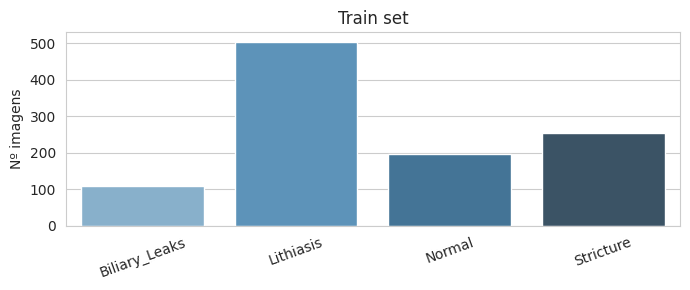

/tmp/ipykernel_57/1568446020.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_names[i] for i in unique], y=counts, palette='Blues_d')


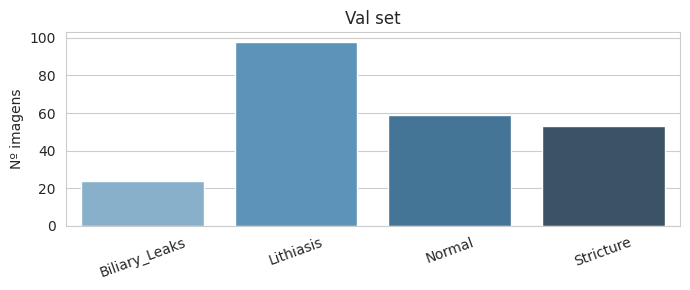

/tmp/ipykernel_57/1568446020.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_names[i] for i in unique], y=counts, palette='Blues_d')


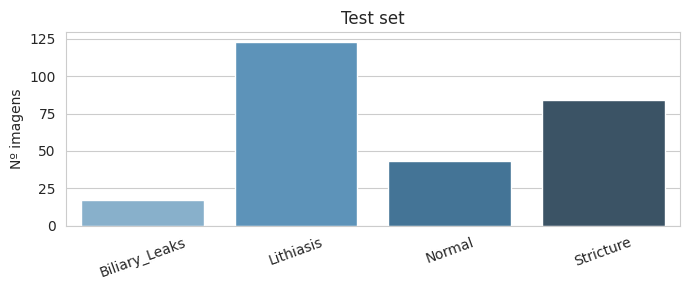

In [8]:
# ── Distribuição de classes ───────────────────────────────────────────────────
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    unique, counts = np.unique(labels, return_counts=True)
    plt.figure(figsize=(7, 3))
    sns.barplot(x=[class_names[i] for i in unique], y=counts, palette='Blues_d')
    plt.title(header); plt.ylabel('Nº imagens')
    plt.xticks(rotation=20)
    plt.tight_layout(); plt.show()

for phase in phases:
    visualize_holdout_balance(data[phase]['labels'], class_names, f'{phase.capitalize()} set')

## Pré-processamento – MELHORIA: CLAHE

O enunciado recomenda explicitamente **CLAHE** (Contrast Limited Adaptive Histogram Equalization) para imagens de fluoroscopia — melhora o contraste local dos ductos biliares sem amplificar ruído.

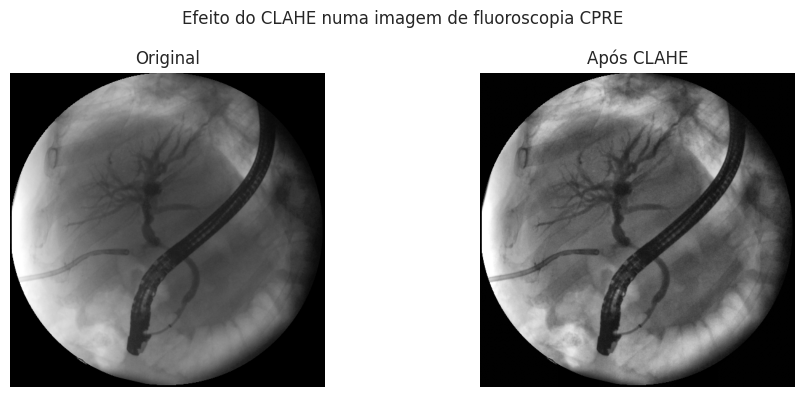

In [11]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image  # <-- Esta é a linha que falta!

def apply_clahe(img_tensor):
    """Aplica CLAHE a cada canal (C,H,W) float em [0,1]."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    arr = img_tensor.numpy()
    out = np.zeros_like(arr)
    for c in range(arr.shape[0]):
        ch = (arr[c] * 255).astype(np.uint8)
        out[c] = clahe.apply(ch).astype(np.float32) / 255.0
    return torch.from_numpy(out)

# Visualização
sample_path = data['train']['images'][0]
original = np.array(Image.open(sample_path).convert('L'))
clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced  = clahe_obj.apply(original)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(original, cmap='gray'); ax1.set_title('Original');    ax1.axis('off')
ax2.imshow(enhanced, cmap='gray'); ax2.set_title('Após CLAHE'); ax2.axis('off')
plt.suptitle('Efeito do CLAHE numa imagem de fluoroscopia CPRE', fontsize=12)
plt.tight_layout()
plt.savefig(f'{model_path}/clahe_example.png', dpi=150)
plt.show()

## Transforms – MELHORIA: mais augmentação + CLAHE + 224×224

Adicionado face ao v0: `RandFlip` (H e V), `RandAffine` (shear leve), `CLAHE`, resolução 224×224.

In [15]:
from monai.transforms import (
    Compose, 
    LoadImage, 
    EnsureChannelFirst, 
    Resize, 
    RandFlip, 
    RandRotate, 
    RandZoom, 
    RandAffine, 
    RandAdjustContrast, 
    RandGaussianNoise, 
    NormalizeIntensity, 
    Lambda, 
    ToTensor,
    Activations, 
    AsDiscrete
)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-11 15:03:14.816926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778511795.029314      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778511795.093770      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778511795.651171      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778511795.651240      57 computation_placer.cc:1

In [16]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),          # 224 em vez de 512
    # ── Augmentação melhorada ──────────────────────────────────────────────
    RandFlip(spatial_axis=0, prob=0.4),    # flip vertical   (novo)
    RandFlip(spatial_axis=1, prob=0.4),    # flip horizontal (novo)
    RandRotate(range_x=15, prob=0.5),
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5),
    RandAffine(shear_range=0.1, prob=0.3), # shear leve      (novo)
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.02),
    # ── Normalização + CLAHE ────────────────────────────────────────────────
    NormalizeIntensity(),
    Lambda(apply_clahe),                   # CLAHE (novo)
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    NormalizeIntensity(),
    Lambda(apply_clahe),
    Lambda(repeat_if_needed),
    ToTensor()
])

act       = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)
print('Transforms definidos. Input size:', IMG_SIZE)

Transforms definidos. Input size: 224


## Dataset, Class Weights e DataLoaders – MELHORIA: class weights

In [21]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from monai.data import Dataset  # Podes usar o Dataset do MONAI ou do PyTorch
from sklearn.utils.class_weight import compute_class_weight

In [22]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]


# ── Class Weights (NOVO) ──────────────────────────────────────────────────────
train_labels_np  = np.array(data['train']['labels'])
class_weights    = compute_class_weight('balanced',
                                         classes=np.arange(num_class),
                                         y=train_labels_np)
class_weights_t  = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights:', {class_names[i]: f'{w:.3f}' for i, w in enumerate(class_weights)})

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds   = MedNISTDataset(data['val']['images'],   data['val']['labels'],   val_transforms)
test_ds  = MedNISTDataset(data['test']['images'],  data['test']['labels'],  val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Class weights: {'Biliary_Leaks': '2.425', 'Lithiasis': '0.528', 'Normal': '1.354', 'Stricture': '1.046'}
Train: 1067 | Val: 234 | Test: 267


## Modelo – MELHORIA: classificador mais profundo + fine-tuning faseado


In [24]:
import torch.nn as nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

def build_model(freeze_backbone=True):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

    # Classificador com camada intermédia + Dropout extra
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_class)
    )

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    return model.to(device)


model = build_model(freeze_backbone=True)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros total: {total:,}  |  treináveis (fase 1): {trainable:,}')

cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 145MB/s]

Parâmetros total: 2,552,836  |  treináveis (fase 1): 328,964


## Mixup e Loss – MELHORIA: CrossEntropy + class weights + label smoothing

No v0 usava-se `FocalLoss` sem class weights. Aqui:
- **CrossEntropyLoss** com `class_weights` para compensar o desequilíbrio
- **Label smoothing = 0.1** para reduzir overconfidence
- **Mixup (α=0.2)** na fase 2 para robustez a artefactos de raios-X

In [25]:
def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

loss_function = nn.CrossEntropyLoss(
    weight=class_weights_t,
    label_smoothing=0.1
)
print('Loss: CrossEntropyLoss (class weights + label_smoothing=0.1)')

Loss: CrossEntropyLoss (class weights + label_smoothing=0.1)


## Função de treino – MELHORIA: gradient clipping + Mixup opcional

In [90]:
!pip install -q livelossplot torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 11.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [92]:
import torch
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot
from torchmetrics.classification import MulticlassF1Score
from monai.metrics import ROCAUCMetric
from monai.data import decollate_batch

def train_model(train_dl, val_dl, model, loss_fn, optimizer, scheduler,
                epochs, name, patience=PATIENCE, use_mixup=False, phase_name=''):

    f1_metric  = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    auc_metric = ROCAUCMetric()
    liveloss   = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}_{phase_name}.png")])

    best_metric, best_epoch = -1.0, -1
    no_improve = 0

    print(f'\n{"="*55}')
    print(f' {phase_name}  |  epochs={epochs}  |  mixup={use_mixup}')
    print(f'{"="*55}')

    for epoch in range(epochs):
        logs = {}
        # ── TREINO ───────────────────────────────────────────────────────────
        model.train()
        running_loss, running_corrects = 0.0, 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train      = torch.tensor([], dtype=torch.long,    device=device)

        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)

            if use_mixup:
                inputs, y_a, y_b, lam = mixup_data(inputs, labels)
                outputs = model(inputs)
                loss    = mixup_criterion(loss_fn, outputs, y_a, y_b, lam)
            else:
                outputs = model(inputs)
                loss    = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # novo
            optimizer.step()

            running_loss     += loss.detach() * inputs.size(0)
            _, preds          = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train      = torch.cat([y_pred_train, outputs], dim=0)
            y_train           = torch.cat([y_train, labels],       dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc  = running_corrects.float() / len(train_dl.dataset)
        f1_train   = f1_metric(y_pred_train.argmax(dim=1), y_train)
        logs['loss']     = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1']       = f1_train.item()

        # ── VALIDAÇÃO ────────────────────────────────────────────────────────
        model.eval()
        val_loss, val_corrects = 0.0, 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                outputs     = model(val_images)
                val_loss   += loss_fn(outputs, val_labels).detach() * val_images.size(0)
                _, preds    = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y      = torch.cat([y, val_labels],   dim=0)

        val_epoch_loss = val_loss / len(val_dl.dataset)
        val_epoch_acc  = val_corrects.float() / len(val_dl.dataset)
        f1_val         = f1_metric(y_pred.argmax(dim=1), y)

        y_onehot   = [to_onehot(i) for i in decollate_batch(y, detach=False)]
        y_pred_act = [act(i) for i in decollate_batch(y_pred)]
        auc_metric(y_pred_act, y_onehot)
        result = auc_metric.aggregate()
        auc_metric.reset()

        logs['val_loss']     = val_epoch_loss.item()
        logs['val_accuracy'] = val_epoch_acc.item()
        logs['val_F1']       = f1_val.item()
        logs['val_AUC']      = result

        scheduler.step()
        liveloss.update(logs)
        liveloss.send()

        print(f'Ep {epoch+1:3d}/{epochs}  loss={epoch_loss:.4f}  val_loss={val_epoch_loss:.4f}  '
              f'F1={f1_train:.4f}  val_F1={f1_val:.4f}  AUC={result:.4f}')

        if f1_val > best_metric:
            best_metric, best_epoch = f1_val.item(), epoch + 1
            torch.save(model.state_dict(), name)
            print(f'  ✔ Melhor modelo guardado (val F1={best_metric:.4f})')
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f'Early stopping na época {epoch+1}. Melhor: época {best_epoch}, val F1={best_metric:.4f}')
            break

    print(f'Fase concluída – melhor val F1: {best_metric:.4f} na época {best_epoch}')
    return best_metric

## Treino – Fase 1: Feature Extraction (backbone congelado)

In [95]:
import time

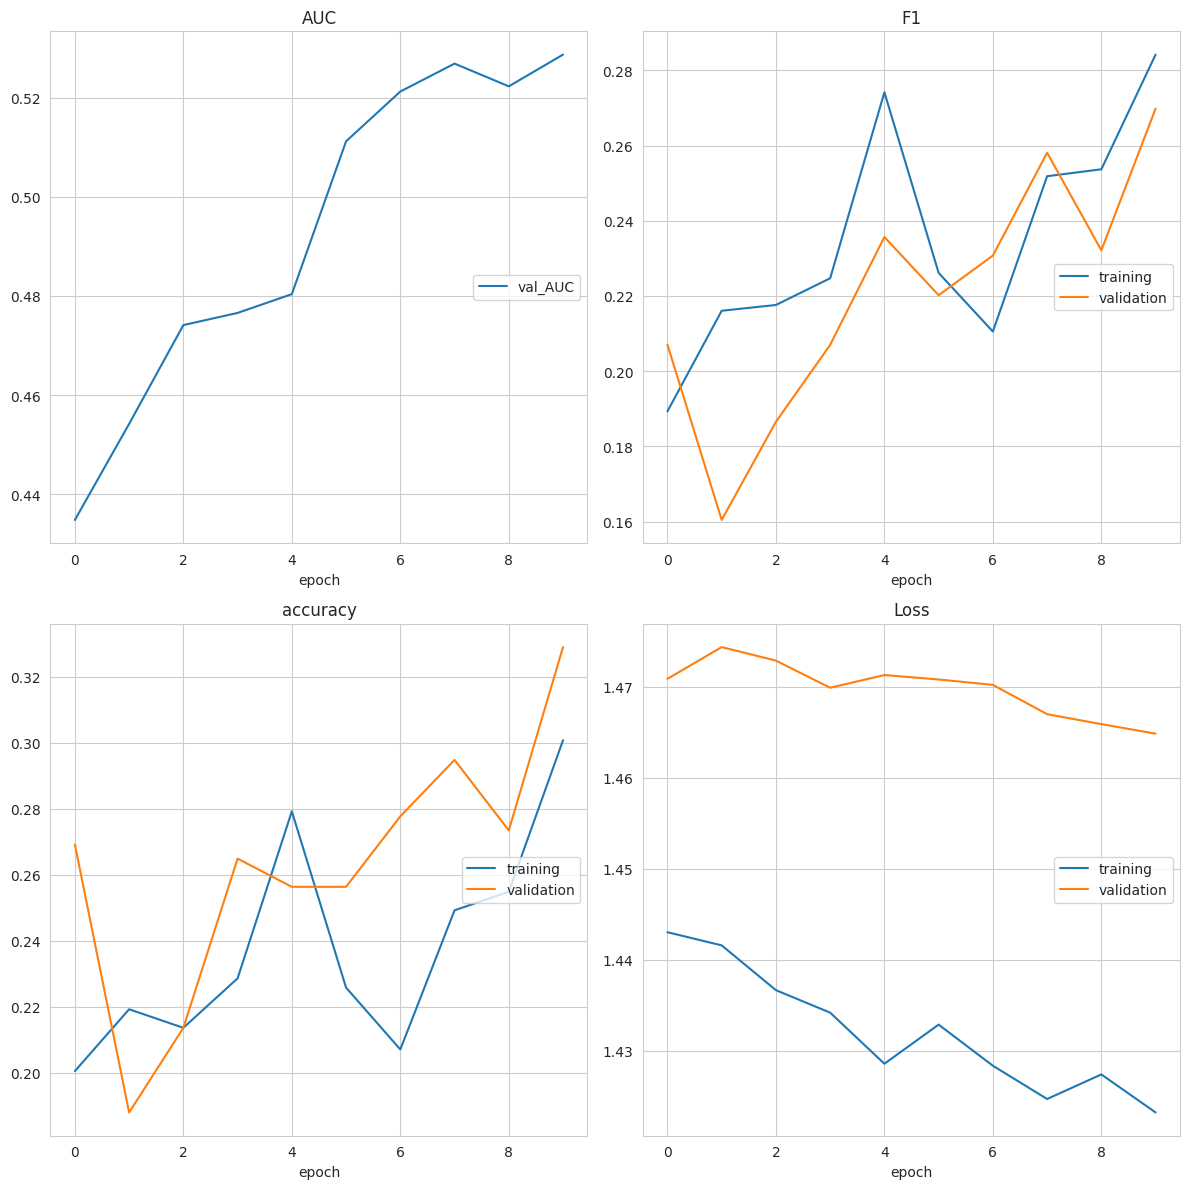

Ep  10/10  loss=1.4232  val_loss=1.4648  F1=0.2842  val_F1=0.2698  AUC=0.5287
  ✔ Melhor modelo guardado (val F1=0.2698)
Fase concluída – melhor val F1: 0.2698 na época 10
Tempo fase 1: 223.6s


In [97]:
set_seed(SEED)
model      = build_model(freeze_backbone=True)
model_name = get_versioned_model_name(model_path + '/mobilenet_v2_improved.pth')

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1, weight_decay=1e-4
)
scheduler_p1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_p1, max_lr=LR_PHASE1,
    steps_per_epoch=len(train_loader), epochs=EPOCHS_PHASE1
)

t0 = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function,
            optimizer_p1, scheduler_p1,
            epochs=EPOCHS_PHASE1, name=model_name,
            patience=PATIENCE, use_mixup=False,
            phase_name='Fase1_FeatureExtraction')
print(f'Tempo fase 1: {time.perf_counter()-t0:.1f}s')

## Treino – Fase 2: Fine-tuning completo + Mixup

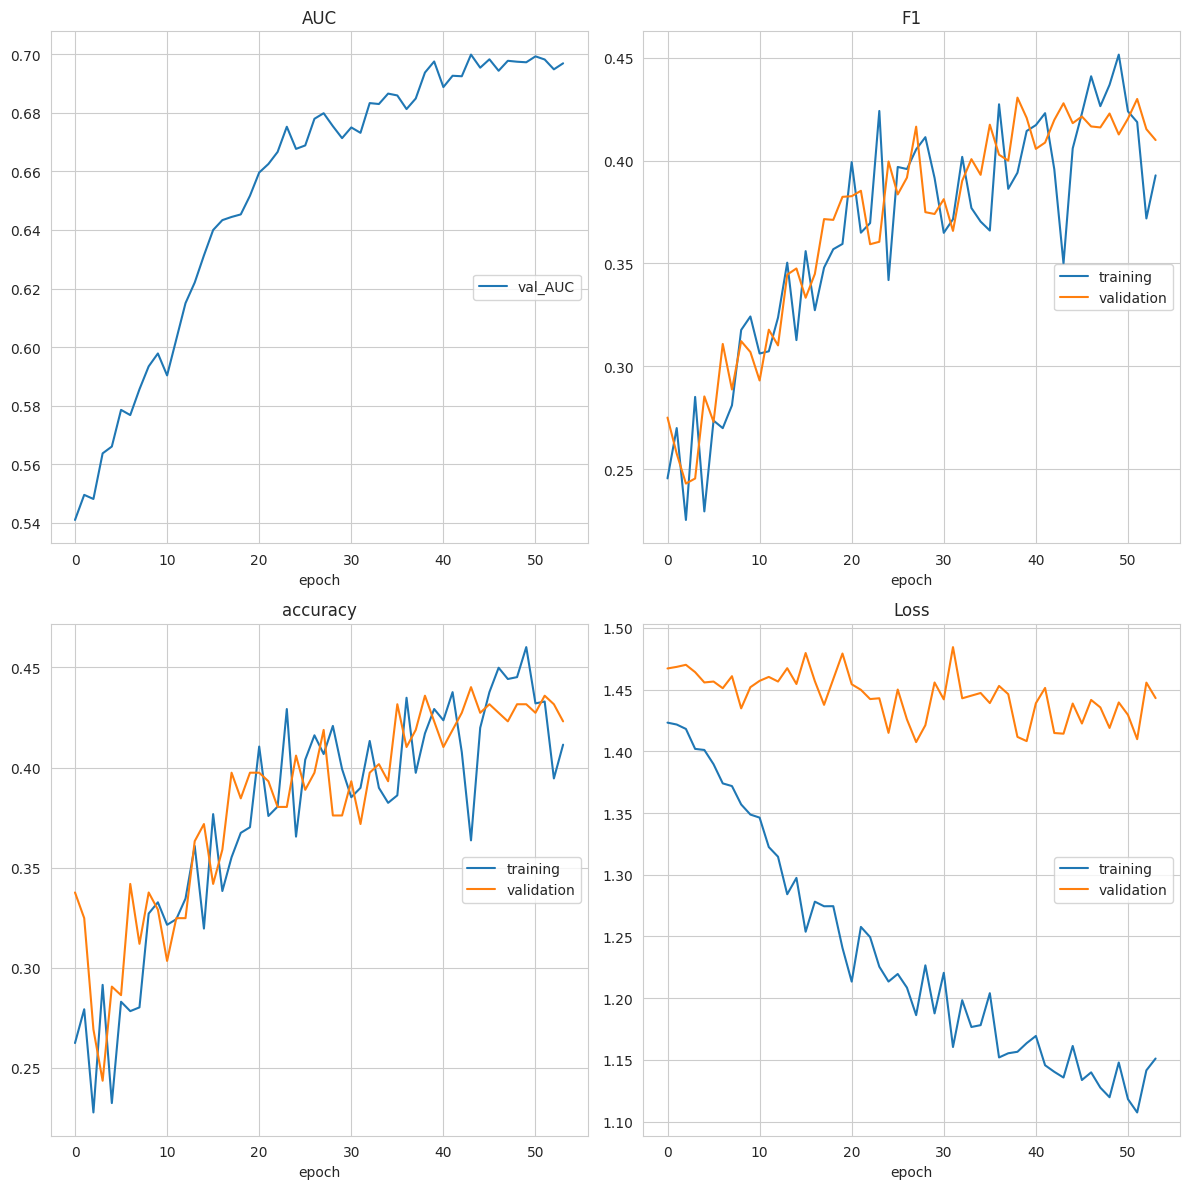

Ep  54/60  loss=1.1512  val_loss=1.4431  F1=0.3928  val_F1=0.4100  AUC=0.6969
Early stopping na época 54. Melhor: época 39, val F1=0.4306
Fase concluída – melhor val F1: 0.4306 na época 39
Tempo fase 2: 1244.0s


In [98]:
# Carrega o melhor da fase 1 e descongela tudo
model.load_state_dict(torch.load(model_name))
for param in model.parameters():
    param.requires_grad = True
print(f'Backbone descongelado. Parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

optimizer_p2 = torch.optim.AdamW(
    model.parameters(), lr=LR_PHASE2, weight_decay=1e-4
)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=EPOCHS_PHASE2, eta_min=1e-7
)

t0 = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function,
            optimizer_p2, scheduler_p2,
            epochs=EPOCHS_PHASE2, name=model_name,
            patience=PATIENCE, use_mixup=True,
            phase_name='Fase2_FineTuning')
print(f'Tempo fase 2: {time.perf_counter()-t0:.1f}s')

## Avaliação no Conjunto de Teste

In [100]:
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

model.load_state_dict(torch.load(model_name))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(device))
        probs   = F.softmax(outputs, dim=1).cpu().numpy()
        preds   = np.argmax(probs, axis=1)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average='macro')

print(f'\n{"="*50}')
print(f' Accuracy  : {acc:.4f}')
print(f' F1-macro  : {f1:.4f}')
print(f' Baseline  : 0.7380  (artigo MIQR-CC)')
print(f' v0 teste  : 0.4564  (FocalLoss sem class weights)')
print(f' Delta vs baseline : {f1-0.738:+.4f}')
print(f'{"="*50}\n')
print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4, zero_division=0))


 Accuracy  : 0.5131
 F1-macro  : 0.4973
 Baseline  : 0.7380  (artigo MIQR-CC)
 v0 teste  : 0.4564  (FocalLoss sem class weights)
 Delta vs baseline : -0.2407

               precision    recall  f1-score   support

Biliary_Leaks     0.3913    0.5294    0.4500        17
    Lithiasis     0.5794    0.5041    0.5391       123
       Normal     0.4889    0.5116    0.5000        43
    Stricture     0.4783    0.5238    0.5000        84

     accuracy                         0.5131       267
    macro avg     0.4845    0.5172    0.4973       267
 weighted avg     0.5210    0.5131    0.5148       267



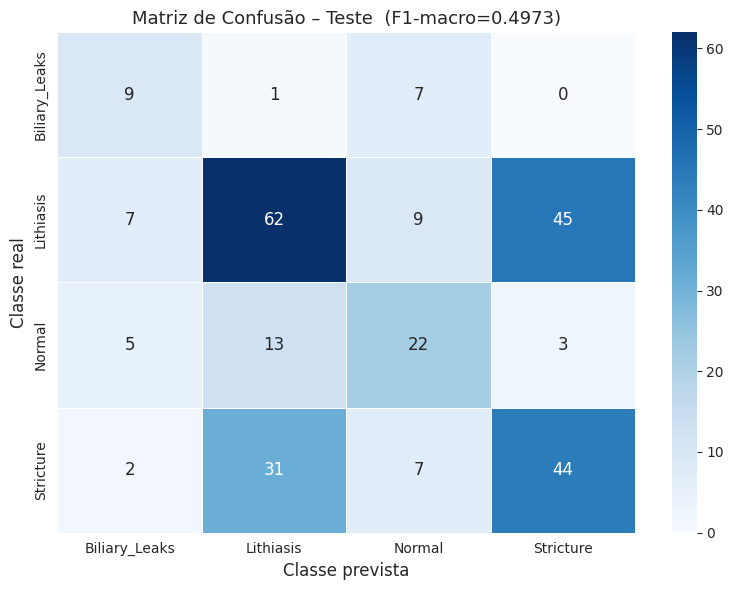

In [102]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 12})
plt.ylabel('Classe real', fontsize=12)
plt.xlabel('Classe prevista', fontsize=12)
plt.title(f'Matriz de Confusão – Teste  (F1-macro={f1:.4f})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{model_path}/confusion_matrix.png', dpi=200)
plt.show()

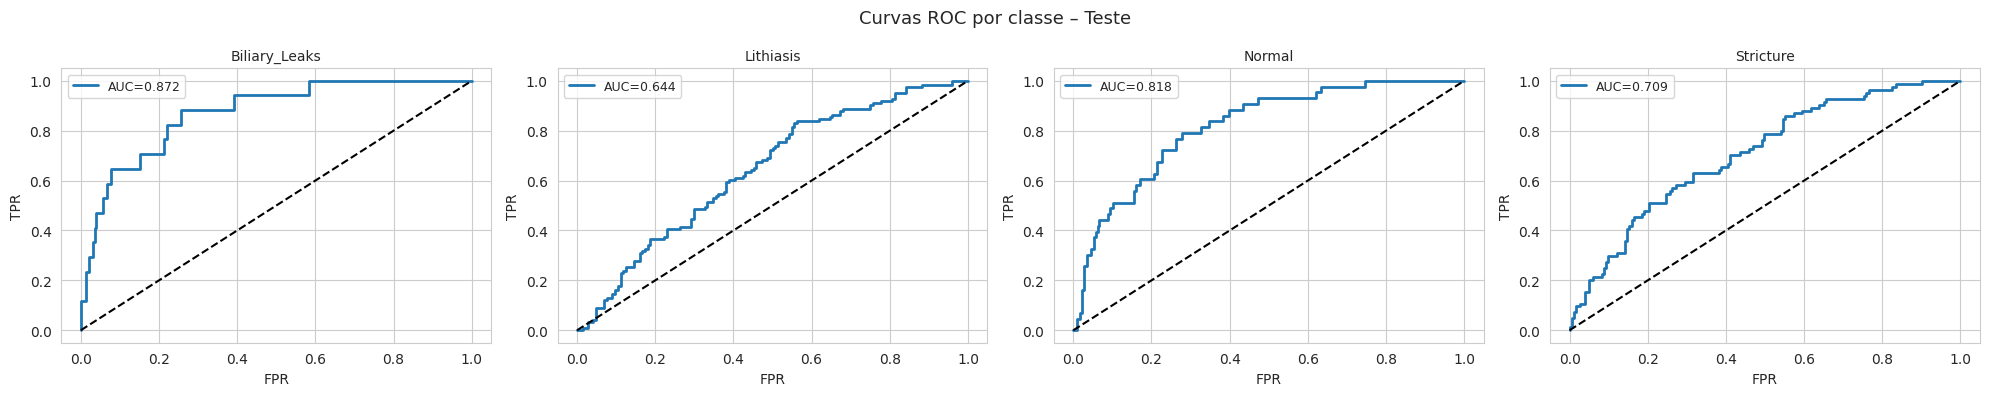

AUC-ROC macro (OvR): 0.7609


In [105]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ── AUC-ROC por classe ────────────────────────────────────────────────────────
y_bin = label_binarize(all_labels, classes=np.arange(num_class))

fig, axes = plt.subplots(1, num_class, figsize=(5*num_class, 4))
for i, (ax, cname) in enumerate(zip(axes, class_names)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = roc_auc_score(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f'AUC={auc_val:.3f}')
    ax.plot([0,1],[0,1],'k--')
    ax.set_title(cname, fontsize=10)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=9)

plt.suptitle('Curvas ROC por classe – Teste', fontsize=13)
plt.tight_layout()
plt.savefig(f'{model_path}/roc_curves.png', dpi=150)
plt.show()

mean_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
print(f'AUC-ROC macro (OvR): {mean_auc:.4f}')

## Grad-CAM – Obrigatório pelo enunciado

Gera mapas de calor que mostram quais regiões da imagem influenciaram a classificação. Para o MobileNetV2 usamos a última camada do backbone (`model.features[-1]`).

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


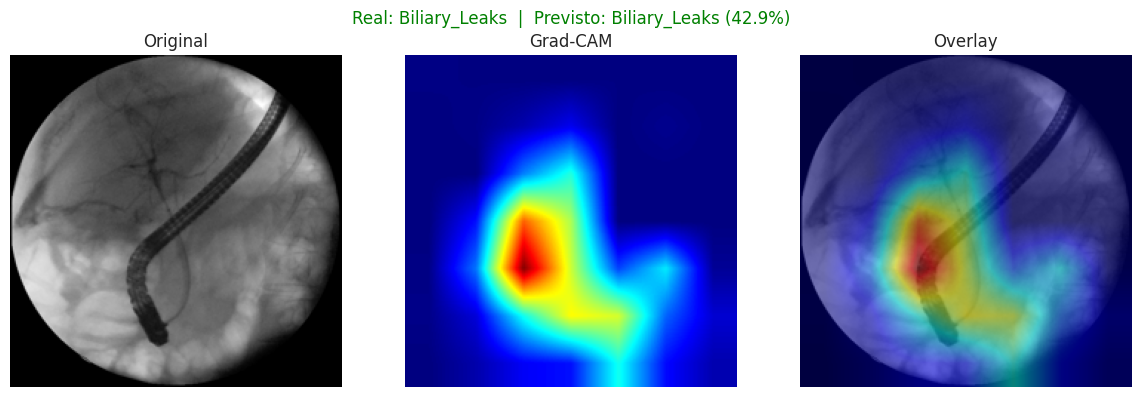

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_0.png


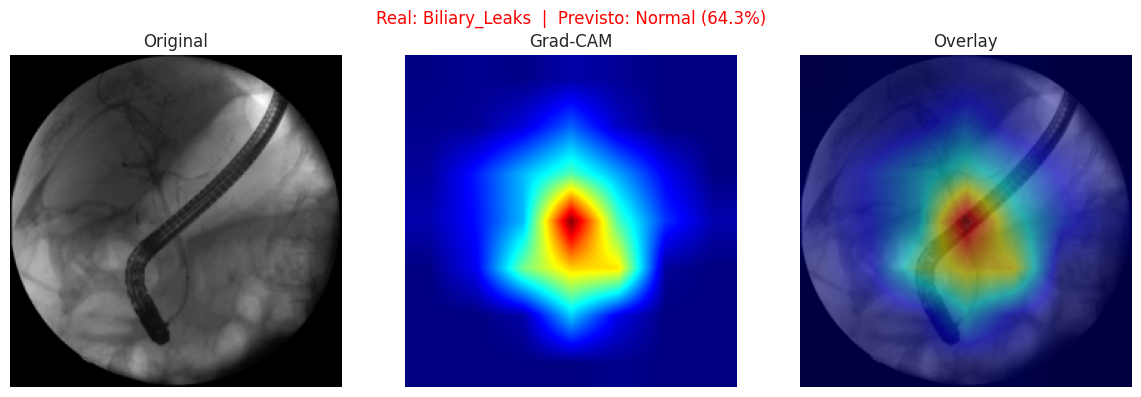

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Biliary_Leaks_1.png


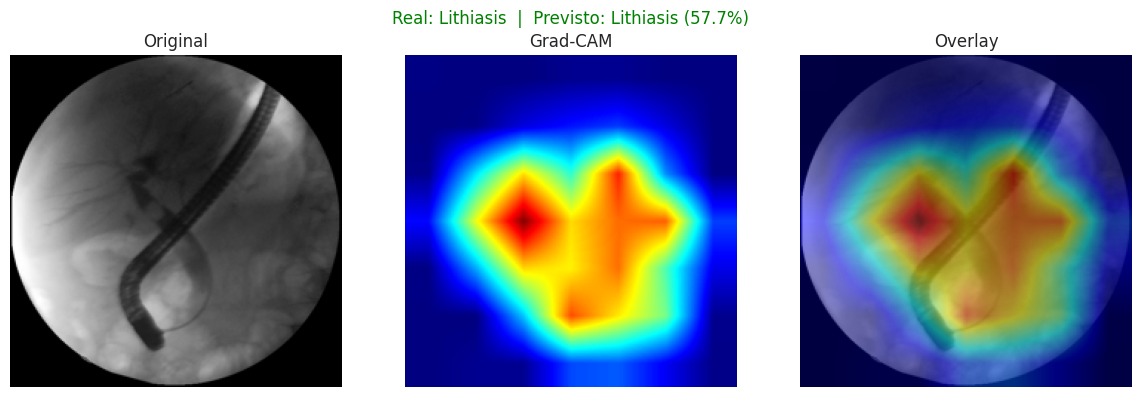

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_0.png


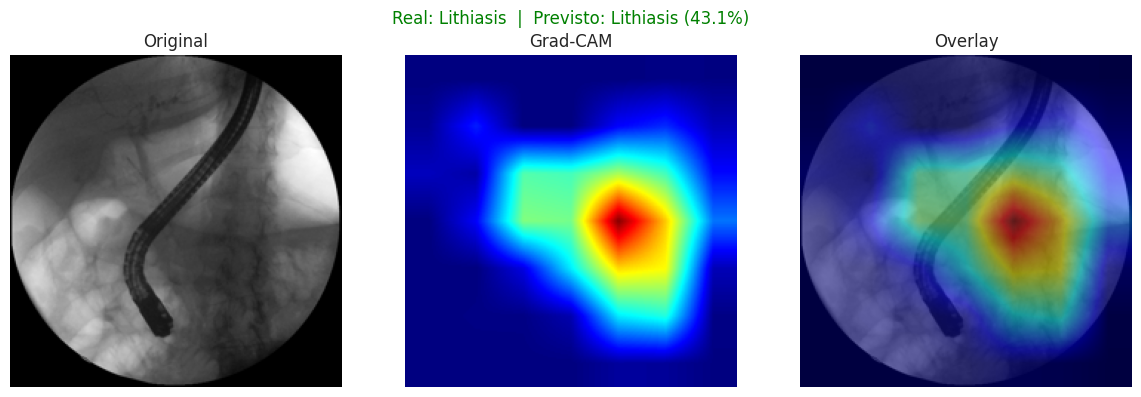

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Lithiasis_1.png


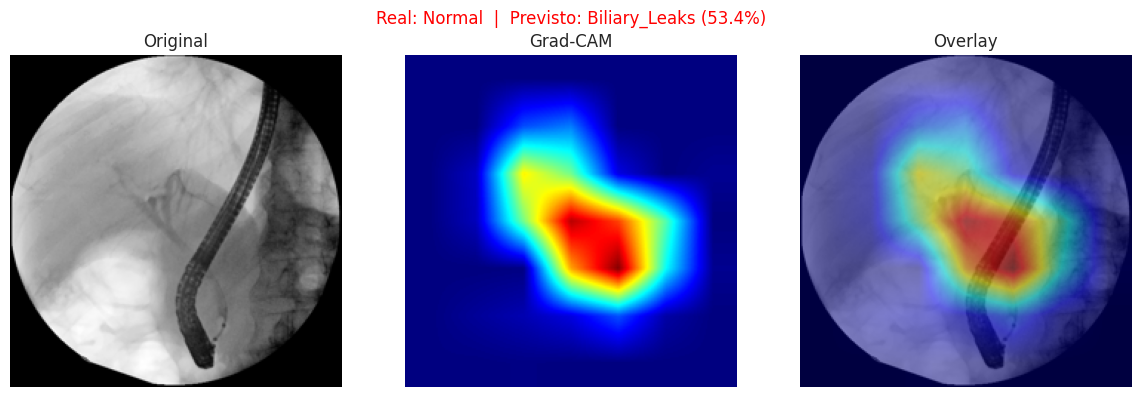

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_0.png


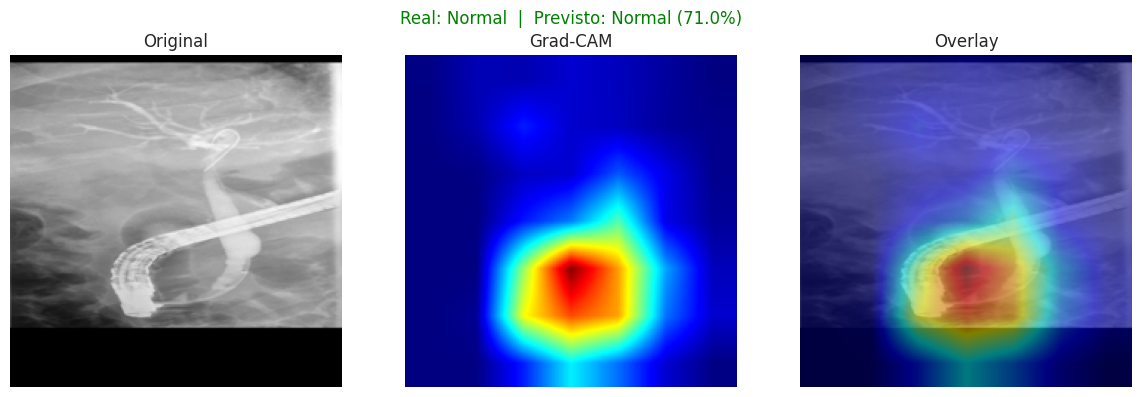

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Normal_1.png


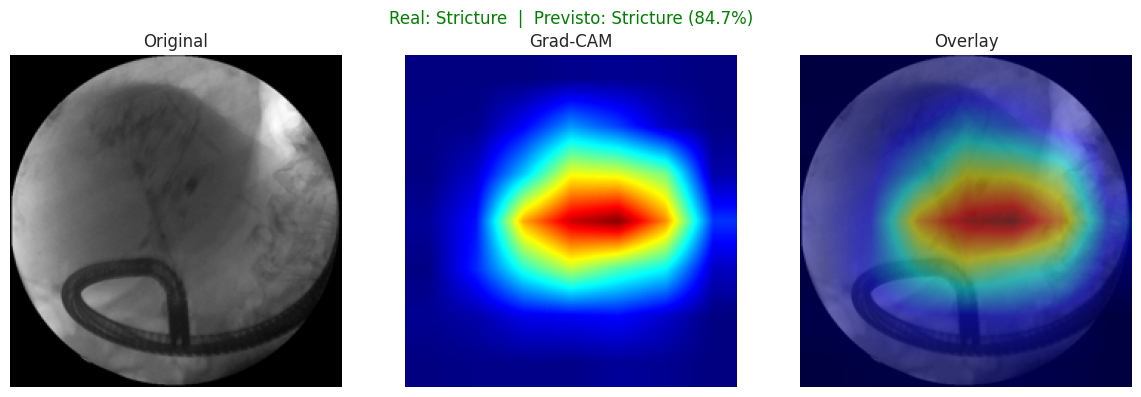

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_0.png


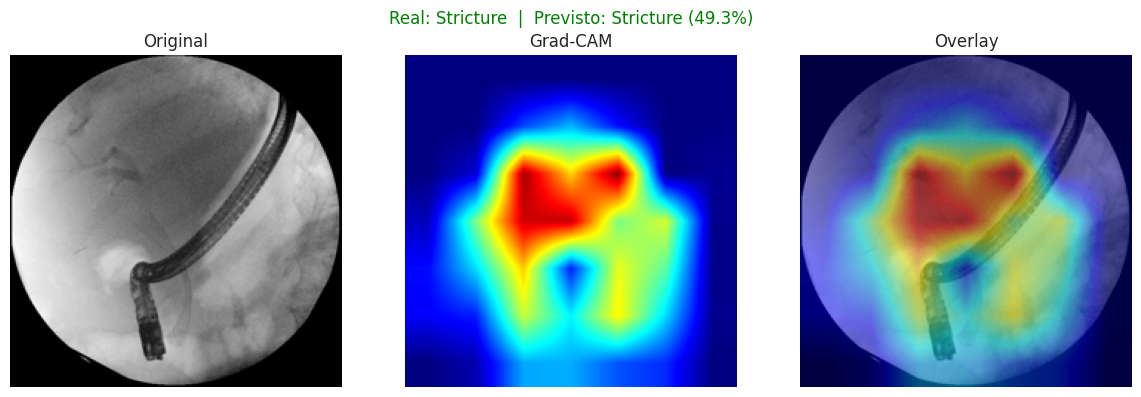

Guardado: /kaggle/working/MIA_AP_my_models/gradcam/gradcam_Stricture_1.png


In [106]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.gradients    = None
        self.activations  = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        x = input_tensor.unsqueeze(0).to(device).requires_grad_(True)
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        self.model.zero_grad()
        oh = torch.zeros_like(out); oh[0, class_idx] = 1.0
        out.backward(gradient=oh)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        prob = F.softmax(out, dim=1)[0, class_idx].item()
        return cam, class_idx, prob


gradcam = GradCAM(model, target_layer=model.features[-1])


def show_gradcam(img_path, true_label, save_path=None):
    img_tensor = val_transforms(img_path)
    cam, pred_idx, prob = gradcam.generate(img_tensor)

    raw = np.array(Image.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE)))
    raw_rgb  = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    cam_r    = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap  = cv2.applyColorMap((cam_r * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap  = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay  = (0.5 * raw_rgb + 0.5 * heatmap).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(heatmap);          axes[1].set_title('Grad-CAM');  axes[1].axis('off')
    axes[2].imshow(overlay);          axes[2].set_title('Overlay');   axes[2].axis('off')
    cor = 'green' if pred_idx == true_label else 'red'
    plt.suptitle(
        f'Real: {class_names[true_label]}  |  Previsto: {class_names[pred_idx]} ({prob:.1%})',
        fontsize=12, color=cor
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


# 2 exemplos por classe
os.makedirs(f'{model_path}/gradcam', exist_ok=True)
for ci, cname in enumerate(class_names):
    imgs = [(img, lbl) for img, lbl in zip(data['test']['images'], data['test']['labels']) if lbl == ci]
    for k, (img_path, lbl) in enumerate(imgs[:2]):
        save_file = f'{model_path}/gradcam/gradcam_{cname}_{k}.png'
        show_gradcam(img_path, lbl, save_path=save_file)
        print(f'Guardado: {save_file}')

## Resumo Final

In [107]:
print('='*60)
print('RESUMO COMPARATIVO')
print('='*60)
print(f'  v0 (professor)  val F1 = 0.5442  |  test F1 = 0.4564')
print(f'  v1 (melhorado)  test F1 = {f1:.4f}')
print(f'  Baseline artigo          = 0.7380')
print(f'  Delta vs baseline        = {f1-0.738:+.4f}')
print('='*60)
print()
print('Ficheiros guardados em:', model_path)
!ls -lh {model_path}

RESUMO COMPARATIVO
  v0 (professor)  val F1 = 0.5442  |  test F1 = 0.4564
  v1 (melhorado)  test F1 = 0.4973
  Baseline artigo          = 0.7380
  Delta vs baseline        = -0.2407

Ficheiros guardados em: /kaggle/working/MIA_AP_my_models
total 21M
-rw-r--r-- 1 root root 305K May 11 15:00 clahe_example.png
-rw-r--r-- 1 root root  83K May 11 16:26 confusion_matrix.png
drwxr-xr-x 2 root root 4.0K May 11 16:26 gradcam
-rw-r--r-- 1 root root  10M May 11 15:30 mobilenet_v2_improved_20260511_152612.pth
-rw-r--r-- 1 root root 123K May 11 15:30 mobilenet_v2_improved_20260511_152612.pth_Fase1_FeatureExtraction.png
-rw-r--r-- 1 root root  10M May 11 15:55 mobilenet_v2_improved_20260511_153514.pth
-rw-r--r-- 1 root root 123K May 11 15:38 mobilenet_v2_improved_20260511_153514.pth_Fase1_FeatureExtraction.png
-rw-r--r-- 1 root root 168K May 11 16:01 mobilenet_v2_improved_20260511_153514.pth_Fase2_FineTuning.png
-rw-r--r-- 1 root root  95K May 11 16:26 roc_curves.png


In [4]:
import os
# Este comando vai procurar onde está a pasta 'train' e imprimir o caminho real
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs:
        print(f"✅ CAMINHO ENCONTRADO: {root}")

✅ CAMINHO ENCONTRADO: /kaggle/input/datasets/filipapereira30/dataset/MIQR-CC-Dataset/training/dataset
✅ CAMINHO ENCONTRADO: /kaggle/input/datasets/filipapereira30/dataset/MIQR-CC-Dataset/training/MIQR-CC-Dataset/training/dataset
